# Synthetic Difference-in-Differences: California Proposition 99

Replicates the R `synthdid` starter code in Python:

```r
library(synthdid)
data('california_prop99')
setup = panel.matrices(california_prop99)
tau.hat = synthdid_estimate(setup$Y, setup$N0, setup$T0)
se = sqrt(vcov(tau.hat, method='placebo'))
sprintf('point estimate: %1.2f', tau.hat)
sprintf('95%% CI (%1.2f, %1.2f)', tau.hat - 1.96 * se, tau.hat + 1.96 * se)
plot(tau.hat)
```

**Dataset:** California Prop 99 (tobacco tax, 1989). Outcome is cigarette consumption (packs per capita). Treatment effect should be approximately -15 to -16 packs per capita.

## 1. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from synthdid import (
    panel_matrices,
    synthdid_estimate,
    vcov,
    synthdid_effect_curve,
    synthdid_controls,
    synthdid_plot,
)

## 2. Load data

In [2]:
DATA_PATH = os.path.join(os.getcwd(), "..", "data", "california_prop99.csv")

df = pd.read_csv(DATA_PATH, sep=None, engine="python")
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Data loaded: 1209 rows × 4 columns


,State,Year,PacksPerCapita,treated
0,Alabama,1970,89.800003,0
1,Arkansas,1970,100.300003,0
2,Colorado,1970,124.800003,0
3,Connecticut,1970,120.000000,0
4,Delaware,1970,155.000000,0


## 3. Convert to matrix format

Equivalent to `panel.matrices()` in R.

In [3]:
setup = panel_matrices(
    df,
    unit="State",
    time="Year",
    outcome="PacksPerCapita",
    treatment="treated",
)

Y = setup["Y"]
N0 = setup["N0"]
T0 = setup["T0"]
unit_names = setup["unit_names"]
time_names = [str(t) for t in setup["time_names"]]

print(f"Matrix dimensions: {Y.shape[0]} units × {Y.shape[1]} time periods")
print(f"Control units (N0): {N0}")
print(f"Pre-treatment periods (T0): {T0}")
print(f"Treated unit(s): {unit_names[N0:]}")
print(f"Treatment starts: {time_names[T0]}")

Matrix dimensions: 39 units × 31 time periods
Control units (N0): 38
Pre-treatment periods (T0): 19
Treated unit(s): ['California']
Treatment starts: 1989


## 4. Estimate treatment effect

Equivalent to `synthdid_estimate()` in R.

In [4]:
tau_hat = synthdid_estimate(
    Y, N0, T0,
    unit_names=unit_names,
    time_names=time_names,
)
print(f"Point estimate: {float(tau_hat):.2f}")

Point estimate: -15.60


## 5. Standard error and confidence interval

Placebo method (Algorithm 4), 200 replications.

In [5]:
np.random.seed(42)
variance = vcov(tau_hat, method="placebo", replications=200)
se = np.sqrt(variance)

ci_lo = float(tau_hat) - 1.96 * se
ci_hi = float(tau_hat) + 1.96 * se

print(f"SE (placebo):  {se:.2f}")
print(f"95% CI:        ({ci_lo:.2f}, {ci_hi:.2f})")

SE (placebo):  9.28
95% CI:        (-33.80, 2.59)


## 6. Period-by-period effect curve

In [6]:
effect_curve = synthdid_effect_curve(tau_hat)
post_years = time_names[T0:]
pd.Series(effect_curve, index=post_years, name="tau(t)").round(2).to_frame()

,tau(t)
1989,-4.84
1990,-4.33
1991,-8.65
1992,-8.42
1993,-12.55
1994,-16.11
1995,-18.91
1996,-19.35
1997,-20.88
1998,-22.78


## 7. Top control units and time periods by weight

In [7]:
print("Top control units by synthetic weight (omega):")
synthdid_controls(tau_hat, weight_type="omega", mass=0.9).round(4)

Top control units by synthetic weight (omega):


,estimate 1
Nevada,0.1245
New Hampshire,0.1050
Connecticut,0.0783
Delaware,0.0704
Colorado,0.0575
Illinois,0.0534
Nebraska,0.0479
Montana,0.0451
Utah,0.0415
New Mexico,0.0406


In [8]:
print("Top pre-treatment periods by weight (lambda):")
synthdid_controls(tau_hat, weight_type="lambda", mass=0.9).round(4)

Top pre-treatment periods by weight (lambda):


,estimate 1
1988,0.4271
1986,0.3665
1987,0.2065


## 8. Plot

/home/me/work/synthdid_python/examples/../synthdid/plot.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


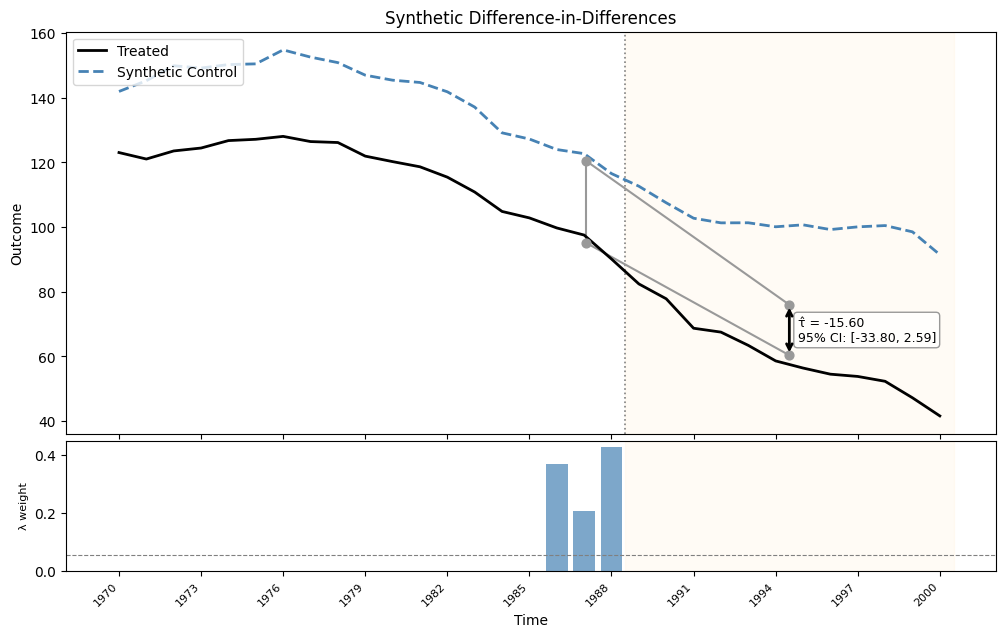

In [9]:
fig = synthdid_plot(tau_hat, se=se, figsize=(12, 7))
plt.show()